In [1]:
# Import libraries
import pandas as pd
import os

print("⏳ Creating sample dataset...")

# Load ONLY first 50,000 rows (efficient)
df = pd.read_csv('data/FinalMlfast.csv', nrows=50000)

# Check shape
print(f"✅ Sample loaded with shape: {df.shape}")

# Save sample INSIDE data folder
output_path = 'data/FinalMlfast_sample.csv'
df.to_csv(output_path, index=False)

# Confirm save
print(f"✅ Sample saved at: {output_path}")

# Check file size
file_size = os.path.getsize(output_path) / 1024**2
print(f"📦 Sample file size: {file_size:.2f} MB")

# Preview
print("\n📋 First 3 rows:")
print(df.head(3))

print("\n📋 Total columns:", len(df.columns))

⏳ Creating sample dataset...
✅ Sample loaded with shape: (50000, 972)
✅ Sample saved at: data/FinalMlfast_sample.csv
📦 Sample file size: 117.60 MB

📋 First 3 rows:
  dep_name  esi   age gender           ethnicity  \
0        B  4.0  40.0   Male  Hispanic or Latino   
1        B  4.0  66.0   Male  Hispanic or Latino   
2        B  2.0  66.0   Male  Hispanic or Latino   

                                        race     lang     religion  \
0                         White or Caucasian  English          NaN   
1  Native Hawaiian or Other Pacific Islander  English  Pentecostal   
2  Native Hawaiian or Other Pacific Islander  English  Pentecostal   

  maritalstatus  employstatus  ... cc_vaginaldischarge cc_vaginalpain  \
0        Single     Full Time  ...                 0.0            0.0   
1       Married  Not Employed  ...                 0.0            0.0   
2       Married  Not Employed  ...                 0.0            0.0   

  cc_weakness cc_wheezing cc_withdrawal-alcohol cc_wo

In [2]:
# -----------------------------
# Feature Selection & ESI Grouping
# -----------------------------

import pandas as pd

# Load dataset (use your sample or full CSV)
df = pd.read_csv('data/FinalMlfast_sample.csv')  # or 'FinalMlfast.csv'

# -----------------------------
# Step 1: Map ESI to 3 classes
# ESI 1-2 -> Severe
# ESI 3   -> Moderate
# ESI 4-5 -> Minor
# -----------------------------
def map_esi(level):
    if level in [1, 2]:
        return 'Severe'
    elif level == 3:
        return 'Moderate'
    elif level in [4, 5]:
        return 'Minor'
    else:
        return None  # if missing or invalid

df['ESI_group'] = df['esi'].apply(map_esi)

# Drop rows with missing ESI_group
df = df.dropna(subset=['ESI_group'])

# -----------------------------
# Step 2: Select relevant features
# -----------------------------

# Demographics
demographics = [
    'age', 'gender', 'ethnicity', 'race', 'lang', 'religion',
    'maritalstatus', 'employstatus', 'dep_name'
]

# Chief complaints (all cc_ columns)
cc_columns = [col for col in df.columns if col.startswith('cc_')]

# Time column
time_columns = ['time'] if 'time' in df.columns else []

# Combine all features
selected_features = demographics + cc_columns + time_columns + ['ESI_group']

# Keep only selected features
df_selected = df[selected_features]

# -----------------------------
# Step 3: Quick checks
# -----------------------------
print(f"Selected dataset shape: {df_selected.shape}")
print(f"Columns included ({len(df_selected.columns)}):\n{df_selected.columns.tolist()}")
print("\nFirst 3 rows:")
print(df_selected.head(3))

# -----------------------------
# Step 4: Save selected dataset for ML training
# -----------------------------
df_selected.to_csv('data/FinalMlfast_selected.csv', index=False)
print("\n✅ Feature selection complete. Saved as 'FinalMlfast_selected.csv'")

Selected dataset shape: (49826, 210)
Columns included (210):
['age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'dep_name', 'cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess', 'cc_addictionproblem', 'cc_agitation', 'cc_alcoholintoxication', 'cc_alcoholproblem', 'cc_allergicreaction', 'cc_alteredmentalstatus', 'cc_animalbite', 'cc_ankleinjury', 'cc_anklepain', 'cc_anxiety', 'cc_arminjury', 'cc_armpain', 'cc_armswelling', 'cc_assaultvictim', 'cc_asthma', 'cc_backpain', 'cc_bleeding/bruising', 'cc_blurredvision', 'cc_bodyfluidexposure', 'cc_breastpain', 'cc_breathingdifficulty', 'cc_breathingproblem', 'cc_burn', 'cc_cardiacarrest', 'cc_cellulitis', 'cc_chestpain', 'cc_chesttightness', 'cc_chills', 'cc_coldlikesymptoms', 'cc_confusion', 'cc_conjunctivitis', 'cc_constipation', 'cc_cough', 'cc_cyst', 'cc_decreasedbloodsugar-symptomatic', 'cc_dehydration', 'cc_dentalpain', 'c

Loaded dataset shape: (49826, 210)
Features shape: (49826, 209), Target shape: (49826,)

Missing values before imputation:
58046
Missing values after imputation: 0
Preprocessed features shape: (49826, 252)
Final check for NaNs: 0
Train shape: (39860, 252), Test shape: (9966, 252)
NaN in X_train: 0
NaN in y_train: 0
Resampled train shape: (51972, 252)

Class distribution after SMOTE:
ESI_group
Minor       17324
Moderate    17324
Severe      17324
Name: count, dtype: int64

Cluster distribution:
cluster
1    3668
0    3325
2    3007
Name: count, dtype: int64


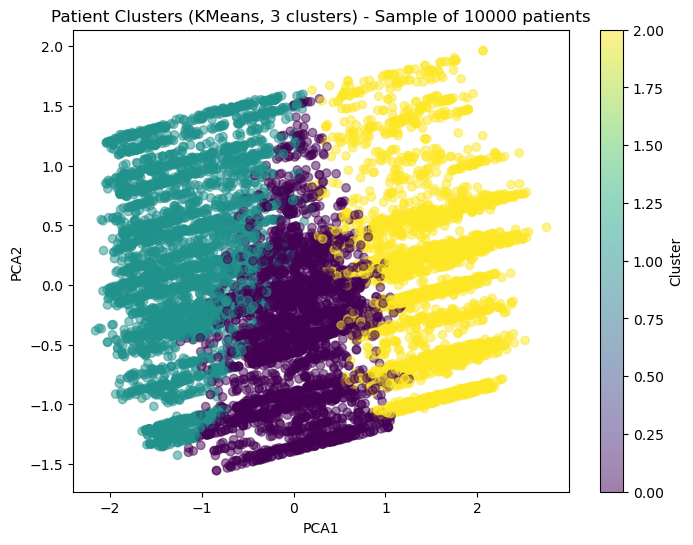


Cluster distribution (sample):
cluster
1    3846
0    3250
2    2904
Name: count, dtype: int64

✅ Preprocessing + clustering complete. Files saved for SNN training.


In [10]:
# -----------------------------
# Full ML Pipeline: Preprocessing + Clustering + Ready for SNN
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# -----------------------------
# Step 1: Load selected dataset
# -----------------------------
df = pd.read_csv('data/FinalMlfast_selected.csv')
print(f"Loaded dataset shape: {df.shape}")

# -----------------------------
# Step 2: Separate features and target
# -----------------------------
demographics = ['gender', 'ethnicity', 'race', 'lang', 'religion',
                'maritalstatus', 'employstatus', 'dep_name']
numerical_features = ['age']
cc_columns = [col for col in df.columns if col.startswith('cc_')]
time_columns = ['time'] if 'time' in df.columns else []

y = df['ESI_group']
X = df[demographics + numerical_features + cc_columns + time_columns].copy()  # Added .copy()

print(f"Features shape: {X.shape}, Target shape: {y.shape}")

# -----------------------------
# Step 3: Handle missing values - FIXED
# -----------------------------
# Check for missing values first
print("\nMissing values before imputation:")
print(X.isnull().sum().sum())

# Impute numerical features
num_imputer = SimpleImputer(strategy='median')
X.loc[:, numerical_features] = num_imputer.fit_transform(X[numerical_features])

# Impute categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')
X.loc[:, demographics] = cat_imputer.fit_transform(X[demographics])

# Check cc_columns for missing values and fill with 0 (since they're binary)
if cc_columns:
    X.loc[:, cc_columns] = X[cc_columns].fillna(0)

# Check time_columns
if time_columns:
    X.loc[:, time_columns] = X[time_columns].fillna(X[time_columns].median())

# Verify no missing values remain
print(f"Missing values after imputation: {X.isnull().sum().sum()}")
assert X.isnull().sum().sum() == 0, "Still have missing values!"

# -----------------------------
# Step 4: Encode categorical features
# -----------------------------
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[demographics])
cat_columns = encoder.get_feature_names_out(demographics)
X_cat_df = pd.DataFrame(X_cat, columns=cat_columns, index=X.index)

# -----------------------------
# Step 5: Scale numerical features
# -----------------------------
scaler = StandardScaler()
X_num = scaler.fit_transform(X[numerical_features])
X_num_df = pd.DataFrame(X_num, columns=numerical_features, index=X.index)

# -----------------------------
# Step 6: Combine all features
# -----------------------------
X_final = pd.concat([X_cat_df, X_num_df, X[cc_columns + time_columns]], axis=1)
print(f"Preprocessed features shape: {X_final.shape}")
print(f"Final check for NaNs: {X_final.isnull().sum().sum()}")

# -----------------------------
# Step 7: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# -----------------------------
# Step 8: Handle class imbalance with SMOTE - FIXED
# -----------------------------
# Verify no NaNs in training data
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in y_train: {y_train.isnull().sum()}")

# Drop any rows with NaN just in case (should be 0)
X_train_clean = X_train.dropna()
y_train_clean = y_train[X_train_clean.index]

if len(X_train_clean) < len(X_train):
    print(f"Dropped {len(X_train) - len(X_train_clean)} rows with NaN")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_clean, y_train_clean)
print(f"Resampled train shape: {X_train_res.shape}")
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

# -----------------------------
# Step 9: Optional Clustering (for EDA)
# -----------------------------
# Use a smaller sample for PCA/clustering if dataset is large
sample_size = min(10000, len(X_final))
X_sample = X_final.sample(n=sample_size, random_state=42)

pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_sample)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_sample = df.loc[X_sample.index].copy()
df_sample['cluster'] = clusters
print("\nCluster distribution:")
print(df_sample['cluster'].value_counts())


# Use the sample you already created for clustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# If you have df_sample from before with clusters
# Re-create it if needed
sample_size = min(10000, len(X_final))
X_sample = X_final.sample(n=sample_size, random_state=42)
df_sample = df.loc[X_sample.index].copy()

# Cluster the sample
kmeans_sample = KMeans(n_clusters=3, random_state=42)
df_sample['cluster'] = kmeans_sample.fit_predict(X_sample)

# PCA on sample
pca_2d = PCA(n_components=2, random_state=42)
X_sample_2d = pca_2d.fit_transform(X_sample)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_sample_2d[:,0], X_sample_2d[:,1], c=df_sample['cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title(f'Patient Clusters (KMeans, 3 clusters) - Sample of {sample_size} patients')
plt.colorbar(scatter, label='Cluster')
plt.show()

print("\nCluster distribution (sample):")
print(df_sample['cluster'].value_counts())
# -----------------------------
# Step 10: Save processed datasets
# -----------------------------
X_train_res.to_csv('data/X_train_res.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
y_train_res.to_csv('data/y_train_res.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print("\n✅ Preprocessing + clustering complete. Files saved for SNN training.")

              precision    recall  f1-score   support

       Minor       0.61      0.79      0.69      2648
    Moderate       0.72      0.53      0.61      4331
      Severe       0.63      0.71      0.67      2987

    accuracy                           0.65      9966
   macro avg       0.65      0.68      0.66      9966
weighted avg       0.66      0.65      0.65      9966

[[2092  324  232]
 [1034 2285 1012]
 [ 299  560 2128]]


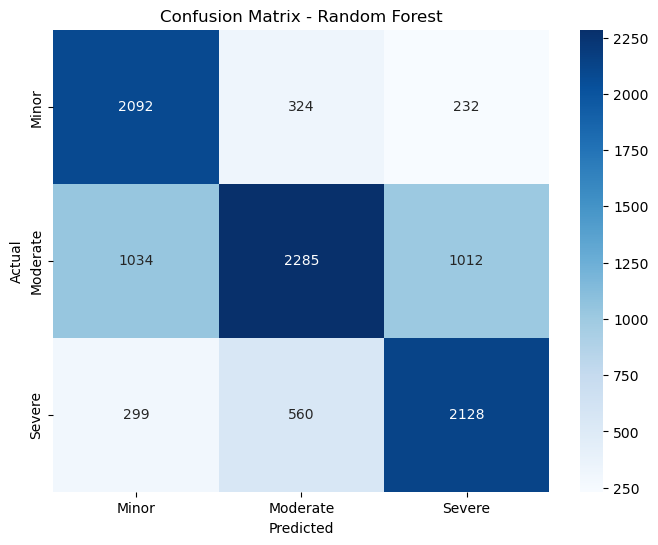

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#trainig random forest as a baseline model 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create RF classifier
rf = RandomForestClassifier(
    n_estimators=200,      # enough trees for good performance
    max_depth=20,          # avoid overfitting, faster training
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

# Train
rf.fit(X_train_res, y_train_res)

# Predict on test
y_pred = rf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))



#visualize the confusion matrix(results from Random Forest)

# True and predicted labels
y_true = y_test  # your test labels
y_pred = rf.predict(X_test)  # predictions from your trained Random Forest

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=['Minor', 'Moderate', 'Severe'])

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Minor', 'Moderate', 'Severe'], yticklabels=['Minor', 'Moderate', 'Severe'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [14]:
#saving the trained Random Forest model for later use in 
import joblib

# Save the trained Random Forest
joblib.dump(rf, 'models/random_forest_model.pkl')

# Later, you can load it like this:
# rf_model = joblib.load('models/random_forest_model.pkl')

['models/random_forest_model.pkl']

In [18]:
#training a simple SNN model 
# -----------------------------
# SNN Training Pipeline
# -----------------------------

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import pandas as pd

# -----------------------------
# Step 1: Encode target labels for SNN
# -----------------------------
# y_train_res and y_test are categorical strings: Minor, Moderate, Severe
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_res)
y_test_enc = label_encoder.transform(y_test)

# Save label encoder for later predictions
joblib.dump(label_encoder, 'models/label_encoder.pkl')

# -----------------------------
# Step 2: Define SNN architecture
# -----------------------------
input_dim = X_train_res.shape[1]  # number of features

model = Sequential([
    Dense(128, input_dim=input_dim, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Step 3: Early stopping to prevent overfitting
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Step 4: Train the model
# -----------------------------
history = model.fit(
    X_train_res, y_train_enc,
    validation_split=0.2,
    epochs=50,          # you can increase/decrease
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# Step 5: Evaluate on test set
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))

# -----------------------------
# Step 6: Save the trained SNN model
# -----------------------------
model.save('models/snn_model.h5')
print("\n✅ SNN trained and saved as 'models/snn_model.h5'")

c:\Users\USer\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6409 - loss: 0.7696 - val_accuracy: 0.7821 - val_loss: 0.5647
Epoch 2/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7087 - loss: 0.6644 - val_accuracy: 0.7818 - val_loss: 0.5420
Epoch 3/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7176 - loss: 0.6441 - val_accuracy: 0.7713 - val_loss: 0.5466
Epoch 4/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7205 - loss: 0.6327 - val_accuracy: 0.7793 - val_loss: 0.5318
Epoch 5/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7251 - loss: 0.6251 - val_accuracy: 0.7557 - val_loss: 0.5552
Epoch 6/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7299 - loss: 0.6146 - val_accuracy: 0.7423 - val_loss: 0.5753
Epoch 7/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7323 - loss: 0.6101 - val_accuracy: 0.8130 - val_loss: 0.4744
Epoch 8/50
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7351 - loss: 0.6018 - val_accuracy: 0.


Classification Report:
              precision    recall  f1-score   support

       Minor       0.72      0.81      0.76      2648
    Moderate       0.71      0.68      0.69      4331
      Severe       0.73      0.69      0.71      2987

    accuracy                           0.72      9966
   macro avg       0.72      0.73      0.72      9966
weighted avg       0.72      0.72      0.72      9966


Confusion Matrix:
[[2153  429   66]
 [ 714 2929  688]
 [ 131  796 2060]]

✅ SNN trained and saved as 'models/snn_model.h5'


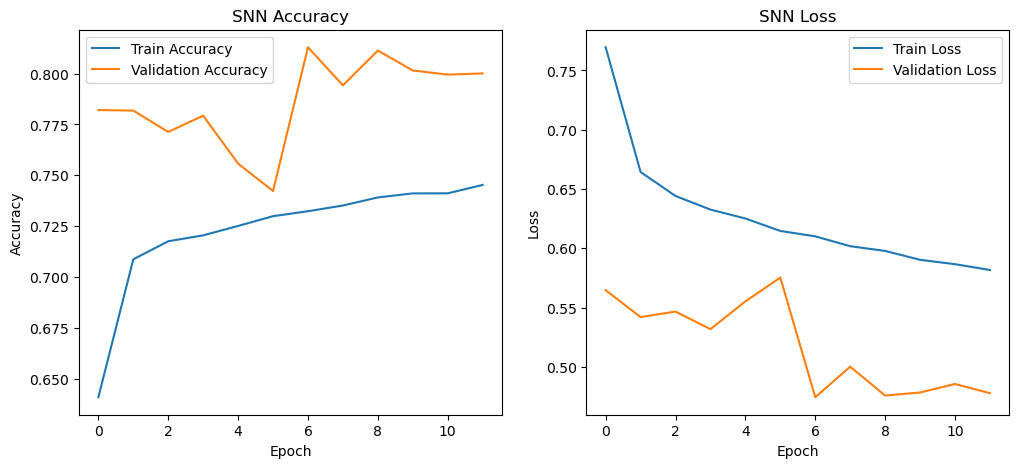

c:\Users\USer\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\USer\anaconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(5000, 252))']
  warnings.warn(msg)
c:\Users\USer\anaconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(10000, 252))']
  warnings.warn(msg)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [21]:

# Visualize Training History + SHAP for SNN

import matplotlib.pyplot as plt
import pickle
import shap
import tensorflow as tf
from tensorflow.keras.models import load_model
import pandas as pd

# -----------------------------
# Step 1: Load the trained model and history
# -----------------------------
snn_model = load_model('models/snn_model.h5')

# If you saved the history separately as a pickle (optional)
#with open('models/snn_history.pkl', 'rb') as f:
    #history = pickle.load(f)

# -----------------------------
# Step 2: Plot training/validation accuracy & loss
# -----------------------------
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('SNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('SNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# -----------------------------
# Step 3: Load features for SHAP
# -----------------------------
X_train_res = pd.read_csv('data/X_train_res.csv')

# -----------------------------
# Step 4: Initialize SHAP explainer
# -----------------------------
# Use a small sample for speed if the dataset is large
sample_size = min(5000, len(X_train_res))
X_sample = X_train_res.sample(n=sample_size, random_state=42)

explainer = shap.DeepExplainer(snn_model, X_sample.values)
shap_values = explainer.shap_values(X_sample.values)

# -----------------------------
# Step 5: Visualize SHAP summary plot
# -----------------------------
# For multi-class, shap_values is a list: one array per class
# You can choose a class index, e.g., 0 = Minor
class_index = 0
shap.summary_plot(shap_values[class_index], X_sample, plot_type="bar")

In [24]:
# -----------------------------
# Full ML Pipeline: BERT + Structured Features + SNN
# -----------------------------

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sentence_transformers import SentenceTransformer

# -----------------------------
# Step 1: Load dataset
# -----------------------------
df = pd.read_csv('data/FinalMlfast_selected.csv')
print(f"Loaded dataset shape: {df.shape}")

# -----------------------------
# Step 2: Separate features and target
# -----------------------------
demographics = ['gender', 'ethnicity', 'race', 'lang', 'religion',
                'maritalstatus', 'employstatus', 'dep_name']
numerical_features = ['age']
cc_columns = [col for col in df.columns if col.startswith('cc_')]
time_columns = ['time'] if 'time' in df.columns else []

# Target
y = df['ESI_group']

# -----------------------------
# Step 3: Preprocess structured features
# -----------------------------
# Encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(df[demographics])
cat_columns = encoder.get_feature_names_out(demographics)
X_cat_df = pd.DataFrame(X_cat, columns=cat_columns, index=df.index)

# Scale numerical features
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numerical_features])
X_num_df = pd.DataFrame(X_num, columns=numerical_features, index=df.index)

# Time features (if present)
X_time_df = df[time_columns] if time_columns else pd.DataFrame()

# -----------------------------
# Step 4: Convert cc_ columns to text for BERT
# -----------------------------
def cc_to_text(row):
    active_cc = [col.replace('cc_', '').replace('_', ' ') for col in cc_columns if row[col] == 1]
    return ' '.join(active_cc) if active_cc else 'none'

df['cc_text'] = df.apply(cc_to_text, axis=1)
print("Sample cc_text:", df['cc_text'].head())

# -----------------------------
# Step 5: Generate BERT embeddings
# -----------------------------
# Use a smaller model for speed; 'all-MiniLM-L6-v2' is fast and works well
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

cc_embeddings = bert_model.encode(df['cc_text'].tolist(), show_progress_bar=True)
X_bert_df = pd.DataFrame(cc_embeddings, index=df.index)
print(f"BERT embeddings shape: {X_bert_df.shape}")

# -----------------------------
# Step 6: Combine all features
# -----------------------------
X_final = pd.concat([X_cat_df, X_num_df, X_time_df, X_bert_df], axis=1)
print(f"Combined feature matrix shape: {X_final.shape}")

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# -----------------------------
# Step 7: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled train shape: {X_train_res.shape}, Test shape: {X_test.shape}")

# -----------------------------
# Step 8: Build SNN model
# -----------------------------
input_dim = X_train_res.shape[1]
num_classes = len(np.unique(y_train_res))

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -----------------------------
# Step 9: Train SNN
# -----------------------------
history = model.fit(
    X_train_res, y_train_res,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    verbose=2
)

# -----------------------------
# Step 10: Evaluate
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Step 11: Save model and label encoder
# -----------------------------
model.save('models/snn_bert_model.h5')
import joblib
joblib.dump(label_encoder, 'models/label_encoder_bert.pkl')

print("\n✅ SNN with BERT trained and saved successfully.")

Loaded dataset shape: (49826, 210)
Sample cc_text: 0    extremitylaceration leginjury
1                motorvehiclecrash
2                        dizziness
3            headachere-evaluation
4                           emesis
Name: cc_text, dtype: object


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\USer\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USer\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1558 [00:00<?, ?it/s]

BERT embeddings shape: (49826, 384)
Combined feature matrix shape: (49826, 437)


TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [ ]:
# -----------------------------
# Full ML Pipeline: BERT + Structured Features + SNN
# Using smaller sample for laptop efficiency
# -----------------------------

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

print("=" * 50)
print("STEP 1: Load dataset with smaller sample")
print("=" * 50)

# -----------------------------
# Step 1: Load dataset (take only 10,000 samples)
# -----------------------------
df_full = pd.read_csv('data/FinalMlfast_selected.csv')
print(f"Full dataset shape: {df_full.shape}")

# Take random sample of 10,000 rows for faster processing
df = df_full.sample(n=10000, random_state=42)
print(f"Sampled dataset shape: {df.shape}")

# -----------------------------
# Step 2: Separate features and target
# -----------------------------
demographics = ['gender', 'ethnicity', 'race', 'lang', 'religion',
                'maritalstatus', 'employstatus', 'dep_name']
numerical_features = ['age']
cc_columns = [col for col in df.columns if col.startswith('cc_')]
time_columns = ['time'] if 'time' in df.columns else []

# Target
y = df['ESI_group']
print(f"\nTarget distribution:\n{y.value_counts()}")

print("\n" + "=" * 50)
print("STEP 2: Preprocess structured features")
print("=" * 50)

# -----------------------------
# Step 3: Preprocess structured features
# -----------------------------
# Encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(df[demographics])
cat_columns = encoder.get_feature_names_out(demographics)
X_cat_df = pd.DataFrame(X_cat, columns=cat_columns, index=df.index)

# Scale numerical features
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numerical_features])
X_num_df = pd.DataFrame(X_num, columns=numerical_features, index=df.index)

# Time features (if present)
if time_columns:
    X_time_df = df[time_columns]
else:
    X_time_df = pd.DataFrame(index=df.index)

print(f"Categorical features: {X_cat_df.shape[1]} columns")
print(f"Numerical features: {X_num_df.shape[1]} columns")
print(f"Time features: {X_time_df.shape[1]} columns")

print("\n" + "=" * 50)
print("STEP 3: Convert cc_ columns to text for BERT")
print("=" * 50)

# -----------------------------
# Step 4: Convert cc_ columns to text for BERT
# -----------------------------
def cc_to_text(row):
    active_cc = [col.replace('cc_', '').replace('_', ' ') for col in cc_columns if row[col] == 1]
    return ' '.join(active_cc) if active_cc else 'none'

df['cc_text'] = df.apply(cc_to_text, axis=1)
print("Sample cc_text:")
print(df['cc_text'].head())

print("\n" + "=" * 50)
print("STEP 4: Generate BERT embeddings (this may take 5-10 minutes)")
print("=" * 50)

# -----------------------------
# Step 5: Generate BERT embeddings
# -----------------------------
# Use a smaller model for speed; 'all-MiniLM-L6-v2' is fast and works well
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

cc_embeddings = bert_model.encode(df['cc_text'].tolist(), show_progress_bar=True)
X_bert_df = pd.DataFrame(cc_embeddings, index=df.index)
print(f"BERT embeddings shape: {X_bert_df.shape}")

print("\n" + "=" * 50)
print("STEP 5: Combine all features")
print("=" * 50)

# -----------------------------
# Step 6: Combine all features
# -----------------------------
X_final = pd.concat([X_cat_df, X_num_df, X_time_df, X_bert_df], axis=1)
# Convert all column names to strings to avoid SMOTE error
X_final.columns = X_final.columns.astype(str)
print(f"Combined feature matrix shape: {X_final.shape}")

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Target classes: {label_encoder.classes_}")

print("\n" + "=" * 50)
print("STEP 6: Train-test split")
print("=" * 50)

# -----------------------------
# Step 7: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nTrain class distribution:")
print(pd.Series(y_train).value_counts())

print("\n" + "=" * 50)
print("STEP 7: Using Class Weights instead of SMOTE (faster)")
print("=" * 50)

# -----------------------------
# Handle class imbalance with Class Weights (faster than SMOTE)
# -----------------------------
# Calculate class weights to handle imbalance
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {weight_dict}")

print("\n" + "=" * 50)
print("STEP 8: Build SNN model")
print("=" * 50)

# -----------------------------
# Step 8: Build SNN model
# -----------------------------
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\n" + "=" * 50)
print("STEP 9: Train SNN model")
print("=" * 50)

# -----------------------------
# Step 9: Train SNN with class weights
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    class_weight=weight_dict,
    verbose=1
)

print("\n" + "=" * 50)
print("STEP 10: Evaluate model")
print("=" * 50)

# -----------------------------
# Step 10: Evaluate
# -----------------------------
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "=" * 50)
print("STEP 11: Save model and preprocessing objects")
print("=" * 50)

# -----------------------------
# Step 11: Save model and preprocessing objects
# -----------------------------
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the SNN model
model.save('models/snn_bert_model.h5')

# Save preprocessing objects for later use in backend
joblib.dump(label_encoder, 'models/label_encoder_bert.pkl')
joblib.dump(encoder, 'models/onehot_encoder.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(bert_model, 'models/bert_model.pkl')

print("\n✅ SNN with BERT trained and saved successfully!")
print("Saved files:")
print("  - models/snn_bert_model.h5")
print("  - models/label_encoder_bert.pkl")
print("  - models/onehot_encoder.pkl")
print("  - models/scaler.pkl")
print("  - models/bert_model.pkl")

# -----------------------------
# Optional: Plot training history
# -----------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot training & validation accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot training & validation loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("Training Complete!")
print("=" * 50)